In [1]:
import pandas as pd 

uva = pd.read_csv('/Users/annayao/dataArt/r1_data/UVA.csv')
uva.head()

,Domain,Group,Field,numpub
0,Health Sciences,Health Professions,Emergency Medical Services,155
1,Health Sciences,Health Professions,General Health Professions,907
2,Health Sciences,Health Professions,Health Information Management,86
3,Health Sciences,Health Professions,Occupational Therapy,37
4,Health Sciences,Health Professions,Pharmacy,65


In [4]:
#top 5 fields by numpub
uva.sort_values(by='numpub', ascending=False).head(10)

,Domain,Group,Field,numpub
65,Life Sciences,"Biochemistry, Genetics and Molecular Biology",Molecular Biology,3461
45,Health Sciences,Medicine,Surgery,2837
146,Physical Sciences,Physics and Astronomy,Astronomy and Astrophysics,1983
197,Social Sciences,Social Sciences,Sociology and Political Science,1895
40,Health Sciences,Medicine,Pulmonary and Respiratory Medicine,1887
16,Health Sciences,Medicine,Epidemiology,1559
189,Social Sciences,Social Sciences,Education,1439
10,Health Sciences,Medicine,Cardiology and Cardiovascular Medicine,1387
89,Physical Sciences,Computer Science,Artificial Intelligence,1368
39,Health Sciences,Medicine,"Public Health, Environmental and Occupational ...",1294



--- Summary DataFrame ---
    year  numpub_per_year
0   2015             5367
1   2016             5594
2   2017             6769
3   2018             5933
4   2019             6326
5   2020             7522
6   2021             7013
7   2022             6875
8   2023             7473
9   2024             7156
10  2025             6028
-------------------------



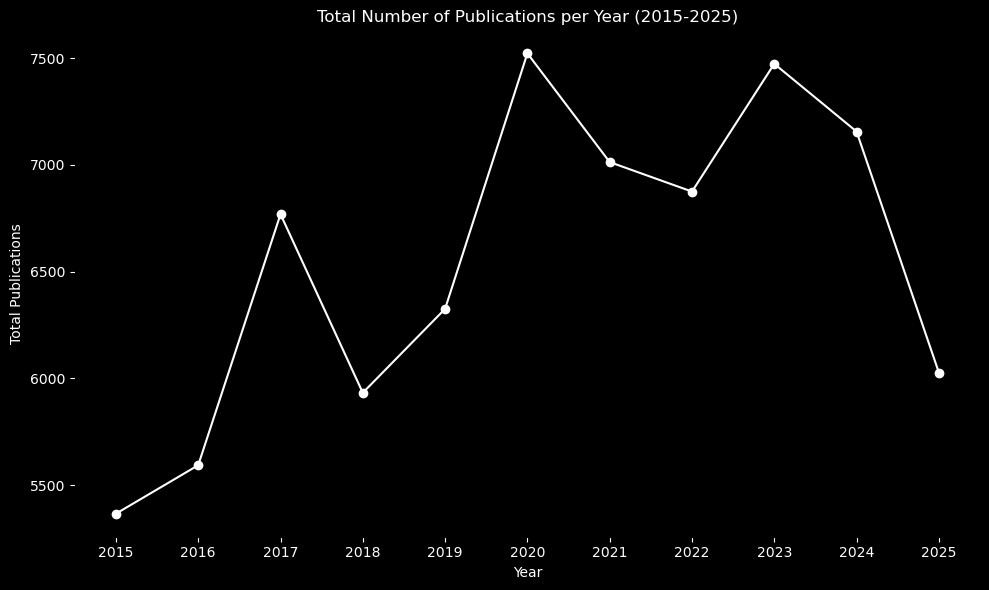

In [7]:
#timeline data
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Define the folder where your CSVs are stored
folder_path = 'timeline_data'

summary_data = []

# 2. Loop through the years 2015 to 2025
for year in range(2015, 2026):
    # Construct the exact file name and path
    filename = f"uva_data_{year}.csv"
    filepath = os.path.join(folder_path, filename)
    
    # 3. Try to read the file and process it
    try:
        # Read the local CSV
        df = pd.read_csv(filepath)
        
        # Check if 'numpub' actually exists in this CSV to prevent errors
        if 'numpub' in df.columns:
            total_numpub = df['numpub'].sum()
            
            # Add the results to our list
            summary_data.append({
                'year': year, 
                'numpub_per_year': total_numpub
            })
        else:
            print(f"Warning: 'numpub' column not found in {filename}")
            
    except FileNotFoundError:
        print(f"Notice: {filename} not found in {folder_path}/. Skipping...")

# 4. Create the new DataFrame from the gathered data
summary_df = pd.DataFrame(summary_data)

# Sort by year to ensure the line graph draws correctly
summary_df = summary_df.sort_values('year')

# Display the new dataframe in the console to verify
print("\n--- Summary DataFrame ---")
print(summary_df)
print("-------------------------\n")

# 5. Generate the line graph
fig, ax = plt.subplots(figsize=(10, 6), facecolor='black')
ax.set_facecolor('black')

# Plot year on X axis, numpub_per_year on Y axis
ax.plot(summary_df['year'], summary_df['numpub_per_year'], marker='o', linestyle='-', color="#FFFFFF")

# Add labels and title
ax.set_title('Total Number of Publications per Year (2015-2025)', color='white')
ax.set_xlabel('Year', color='white')
ax.set_ylabel('Total Publications', color='white')

# Clean up the X-axis to show exact years only
ax.set_xticks(summary_df['year'])
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')


# Show the plot
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import os
import glob

# 1. Setup paths
input_folder = 'timeline_data'
output_folder = 'timeline_data_fixed' 
file_pattern = os.path.join(input_folder, 'uva_data_*.csv')

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print("Scanning files to build master field and domain list...\n")
all_files = glob.glob(file_pattern)

master_field_domain_map = {}

# 2. First Pass: Build the complete dictionary of fields and domains
for file in all_files:
    df = pd.read_csv(file)
    df.columns = df.columns.str.lower() 
    
    # --- NEW CODE: Print the number of unique fields in this specific CSV ---
    if 'field' in df.columns:
        num_unique = df['field'].nunique()
        print(f"{os.path.basename(file)} has {num_unique} unique fields.")
    # ------------------------------------------------------------------------

    if 'field' in df.columns and 'domain' in df.columns:
        for index, row in df.iterrows():
            field = row['field']
            domain = row['domain']
            
            if field not in master_field_domain_map:
                if pd.notna(domain):
                    master_field_domain_map[field] = domain
                else:
                    master_field_domain_map[field] = "Unknown" 
    else:
        print(f"Warning: 'field' or 'domain' column missing in {os.path.basename(file)}")

master_fields_list = sorted(list(master_field_domain_map.keys()))
print(f"\nTotal: Found {len(master_fields_list)} UNIQUE fields across ALL years combined.\n")

Scanning files to build master field and domain list...

uva_data_2011.csv has 207 unique fields.
uva_data_2010.csv has 204 unique fields.
uva_data_2012.csv has 209 unique fields.
uva_data_2013.csv has 210 unique fields.
uva_data_2017.csv has 216 unique fields.
uva_data_2016.csv has 210 unique fields.
uva_data_2014.csv has 205 unique fields.
uva_data_2015.csv has 211 unique fields.
uva_data_2018.csv has 213 unique fields.
uva_data_2024.csv has 218 unique fields.
uva_data_2025.csv has 223 unique fields.
uva_data_2019.csv has 210 unique fields.
uva_data_2022.csv has 218 unique fields.
uva_data_2023.csv has 215 unique fields.
uva_data_2021.csv has 213 unique fields.
uva_data_2020.csv has 220 unique fields.

Total: Found 239 UNIQUE fields across ALL years combined.



In [10]:

# 3. Second Pass: Rewrite each CSV with the master list and domains
print("Processing and standardizing files...")

for file in all_files:
    # Read the original data for this specific year
    df = pd.read_csv(file)
    df.columns = df.columns.str.lower()
    
    filename = os.path.basename(file)
    
    # Create an empty list to hold our standardized rows for this year
    standardized_rows = []
    
    # Convert the original dataframe into a dictionary for fast lookups
    # Key: field, Value: numpub
    current_year_data = {}
    if 'field' in df.columns and 'numpub' in df.columns:
        current_year_data = dict(zip(df['field'], df['numpub']))
    
    # Loop through our master list of EVERY field that exists in ANY year
    for field in master_fields_list:
        # Get the domain from our master map
        domain = master_field_domain_map[field]
        
        # Check if this field actually had publications in this specific year
        if field in current_year_data:
            # If yes, use the real number
            numpub = current_year_data[field]
        else:
            # If no, set it to 0
            numpub = 0
            
        # Append the standardized row
        standardized_rows.append({
            'field': field,
            'domain': domain,
            'numpub': numpub
        })
        
    # Convert our list of standardized rows back into a DataFrame
    standardized_df = pd.DataFrame(standardized_rows)
    
    # Save the standardized data to the new folder
    output_path = os.path.join(output_folder, filename)
    standardized_df.to_csv(output_path, index=False)
    
    print(f"Saved standardized {filename}")

print("\nDone! All files now contain the exact same fields and domains.")

Processing and standardizing files...
Saved standardized uva_data_2011.csv
Saved standardized uva_data_2010.csv
Saved standardized uva_data_2012.csv
Saved standardized uva_data_2013.csv
Saved standardized uva_data_2017.csv
Saved standardized uva_data_2016.csv
Saved standardized uva_data_2014.csv
Saved standardized uva_data_2015.csv
Saved standardized uva_data_2018.csv
Saved standardized uva_data_2024.csv
Saved standardized uva_data_2025.csv
Saved standardized uva_data_2019.csv
Saved standardized uva_data_2022.csv
Saved standardized uva_data_2023.csv
Saved standardized uva_data_2021.csv
Saved standardized uva_data_2020.csv

Done! All files now contain the exact same fields and domains.
